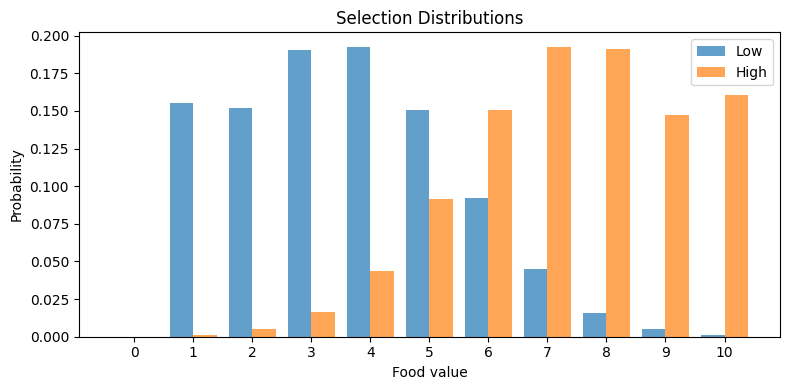

  feet stripes image_file
0    C       W    W_C.png
1    C       E    E_C.png
2    F       W    W_F.png
3    F       E    E_F.png
feet C_high 18
feet C_low 22
feet F_high 22
feet F_low 18
stripes W_high 19
stripes W_low 21
stripes E_high 21
stripes E_low 19
feet C_high 17
feet C_low 23
feet F_high 23
feet F_low 17
stripes W_high 19
stripes W_low 21
stripes E_high 21
stripes E_low 19
feet C_high 26
feet C_low 14
feet F_high 14
feet F_low 26
stripes W_high 20
stripes W_low 20
stripes E_high 20
stripes E_low 20
feet C_high 15
feet C_low 25
feet F_high 25
feet F_low 15
stripes W_high 16
stripes W_low 24
stripes E_high 24
stripes E_low 16
feet C_high 19
feet C_low 21
feet F_high 21
feet F_low 19
stripes W_high 24
stripes W_low 16
stripes E_high 16
stripes E_low 24
feet C_high 22
feet C_low 18
feet F_high 18
feet F_low 22
stripes W_high 29
stripes W_low 11
stripes E_high 11
stripes E_low 29
feet C_high 21
feet C_low 19
feet F_high 19
feet F_low 21
stripes W_high 20
stripes W_low 20
stripes E

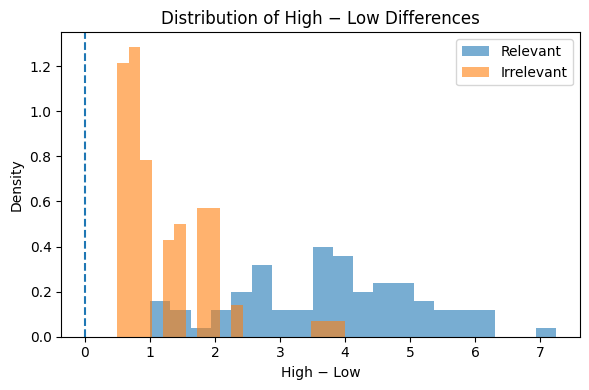

In [7]:
# -*- coding: utf-8 -*-
"""
Created on Tue Oct 28 2025

@author: Sebastian Montesinos

Produces the sequence of trials for each participant, using an additive rule:
- What features are assigned to be relevant are randomly assigned
"""

import itertools
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import json
from collections import Counter, defaultdict

# ============================
# --- Parameters ---
# ============================
mean_high = 7.5
mean_low = 3.5
std_dev = 2
participants = 80
mac = 1
save_csv = True
mac = True
if mac:
    output_dir = r'/Users/sm6511/Desktop/Prediction-Accomodation-Exp/TrialFiles/Main4-29-26'
else:
    output_dir = r'C:\Users\Seb\Desktop\P-A Scripts\Prediction-Accomodation-Exp\TrialFiles\Main4-29-26'

os.makedirs(output_dir, exist_ok=True)
training_reps = 2
testing = 0
visualize = 1

# ============================
# --- Visualize Distributions ---
# ============================
n_samples = 100000

low_samples = np.random.normal(mean_low, std_dev, n_samples)
low_samples = np.clip(np.round(low_samples), 1, 10).astype(int)

high_samples = np.random.normal(mean_high, std_dev, n_samples)
high_samples = np.clip(np.round(high_samples), 1, 10).astype(int)

low_counts = np.bincount(low_samples, minlength=11)
high_counts = np.bincount(high_samples, minlength=11)
values = np.arange(0, 11)

if visualize:
    plt.figure(figsize=(8, 4))
    plt.bar(values - 0.2, low_counts / n_samples, width=0.4, alpha=0.7, label="Low")
    plt.bar(values + 0.2, high_counts / n_samples, width=0.4, alpha=0.7, label="High")
    plt.xticks(values)
    plt.xlabel("Food value")
    plt.ylabel("Probability")
    plt.title("Selection Distributions")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===========================
# --- Stimulus Setup ---
# ============================
feet = ["C", "F"]        # Claws / Webbed feet
stripes = ["W", "E"]     # West / East stripes

stimuli = []

for f, s in itertools.product(feet, stripes):
    stimuli.append({
        "feet": f,
        "stripes": s,
        "image_file": f"{s}_{f}.png"
    })

stim_df = pd.DataFrame(stimuli)

print(stim_df)

FEATURES = ["feet", "stripes"]

FEATURE_OPTIONS = {
    "feet": ("C", "F"),
    "stripes": ("W", "E")
}

direction_counts = {
    "feet": Counter(),
    "stripes": Counter()
}

# ============================
# --- Feature Mapping and Counterbalancing ---
# ============================
def feature_mapping(participant_id):
    """
    Two features total.
    Exactly one is relevant.
    Relevance and direction are counterbalanced.
    """
    relevant_dim = FEATURES[(participant_id - 1) % 2]
    irrelevant_dim = FEATURES[1 - ((participant_id - 1) % 2)]

    options = FEATURE_OPTIONS[relevant_dim]

    direction_idx = ((participant_id - 1) // 2) % 2

    high = options[direction_idx]
    low = options[1 - direction_idx]

    fmap = {
        "relevant_dim": relevant_dim,
        "irrelevant_dim": irrelevant_dim,
        "assignments": {
            relevant_dim: {
                "high": high,
                "low": low
            }
        }
    }

    return fmap

# ============================
# --- Sampling Function ---
# ============================
def sample_additive(stim_row, fmap):
    """
    Single-draw food sampling based on ONE relevant feature.
    """
    dim = fmap["relevant_dim"]
    val = stim_row[dim]

    if val == fmap["assignments"][dim]["high"]:
        draw = np.random.normal(mean_high, std_dev)
    else:
        draw = np.random.normal(mean_low, std_dev)

    draw_clipped = np.clip(draw, 0, 10)
    return int(np.clip(round(draw_clipped), 1, 10))

# ============================
# --- Label Categories in dataframe ---
# ============================
def label_category(row, fmap):
    score = 0
    dim = fmap["relevant_dim"]
    if row[dim] == fmap["assignments"][dim]["high"]:
        score += 1
    return ["low", "high"][score]

def map_relative_features(row, rel_map):
    return pd.Series({
        "feet_rel": rel_map[("feet", row["feet"])],
        "stripes_rel": rel_map[("stripes", row["stripes"])]
    })

def parse_image_name(img_name):
    base = os.path.basename(img_name).replace(".png", "")
    parts = base.split("_")

    # expecting: stripes, feet   e.g., W_C
    s = parts[0]
    f = parts[1]

    return {"feet": f, "stripes": s}

def label_image_sequence(images_list_str, fmap):
    img_list = images_list_str.split(",")

    categories = []
    for img in img_list:
        row = parse_image_name(img)
        cat = label_category(row, fmap)
        categories.append(cat)

    return ",".join(categories)

def infer_irrelevant_high_low(df, fmap):
    """
    Infer high/low labels for the irrelevant dimension based on
    empirical mean food amount in training data.
    """
    ir_dim = fmap["irrelevant_dim"]

    means = (
        df.groupby(ir_dim)["fertility_score"]
        .mean()
        .sort_values()
    )

    low_val = means.index[0]
    high_val = means.index[-1]
    mean_diff = means.iloc[-1] - means.iloc[0]

    return {"high": high_val, "low": low_val}, mean_diff

# ============================
# --- Trial Generation ---
# ============================
def generate_trials(fmap, training_reps, participant_id):
    """
    Create a dataframe with randomized training trials for one participant.
    """
    mean_diff = 0
    while mean_diff < 0.5:
        training_trials = []
        for i in range(training_reps):
            shuffled = stim_df.sample(frac=1).reset_index(drop=True)
            shuffled["phase"] = "training"
            shuffled["rep"] = i + 1
            shuffled["trial_num"] = range(
                1 + i * len(shuffled),
                1 + (i + 1) * len(shuffled)
            )

            shuffled["fertility_score"] = shuffled.apply(
                lambda row: sample_additive(row, fmap),
                axis=1
            )

            shuffled["category"] = [
                label_category(row, fmap) for _, row in shuffled.iterrows()
            ]

            shuffled["relevant_dim"] = fmap["relevant_dim"]
            shuffled["irrelevant_dim"] = fmap["irrelevant_dim"]

            dim = fmap["relevant_dim"]
            shuffled[f"{dim}_high"] = fmap["assignments"][dim]["high"]
            shuffled[f"{dim}_low"] = fmap["assignments"][dim]["low"]

            training_trials.append(shuffled)

        training_df = pd.concat(training_trials, ignore_index=True)
        ir_dim = fmap["irrelevant_dim"]
        ir_info, mean_diff = infer_irrelevant_high_low(training_df, fmap)

    training_df[f"{ir_dim}_high"] = ir_info["high"]
    training_df[f"{ir_dim}_low"] = ir_info["low"]
    training_df["participant_id"] = participant_id
    training_df["rep_image_file"] = training_df["fertility_score"].astype(str) + "_score.png"

    return training_df

# ============================
# --- Run Experiment Generation ---
# ============================
while True:
    irrelevant_counts = Counter()
    relevant_dir_counts = defaultdict(lambda: Counter())
    irrelevant_dir_counts = defaultdict(lambda: Counter())
    all_data = []

    for participant_id in range(1, participants + 1):
        fmap = feature_mapping(participant_id)

        df = generate_trials(
            fmap,
            training_reps=training_reps,
            participant_id=participant_id
        )

        irrelevant_counts[fmap["irrelevant_dim"]] += 1

        dim = fmap["relevant_dim"]
        high = fmap["assignments"][dim]["high"]
        low = fmap["assignments"][dim]["low"]
        relevant_dir_counts[dim][f"{high}_high"] += 1
        relevant_dir_counts[dim][f"{low}_low"] += 1

        dim = fmap["irrelevant_dim"]
        high = df[f"{dim}_high"].iloc[0]
        low = df[f"{dim}_low"].iloc[0]

        irrelevant_dir_counts[dim][f"{high}_high"] += 1
        irrelevant_dir_counts[dim][f"{low}_low"] += 1

        fixed_images = [
            "Resources/W_C.png", "Resources/W_F.png",
            "Resources/E_C.png", "Resources/E_F.png"
        ]

        rand_images = np.random.permutation(fixed_images).tolist()
        df["images_list"] = ",".join(rand_images)
        df["testing_categories"] = df["images_list"].apply(lambda x: label_image_sequence(x, fmap))

        all_data.append(df)

        if save_csv:
            out_path = os.path.join(output_dir, f"subj{participant_id:03d}_training.csv")
            df.to_csv(out_path, index=False)

    if testing:
        all_data_df = pd.concat(all_data, ignore_index=True)
        all_data_df.to_csv(os.path.join(output_dir, "all_trials.csv"), index=False)

    feet_counts = irrelevant_dir_counts["feet"]

    balanced = True

    for dim, values in [("feet", ["C", "F"]), ("stripes", ["W", "E"])]:
        counts = irrelevant_dir_counts[dim]

        for val in values:
            high_key = f"{val}_high"
            low_key  = f"{val}_low"

            print(dim, high_key, counts[high_key])
            print(dim, low_key, counts[low_key])

            if counts[high_key] != counts[low_key]:
                balanced = False

    if balanced:
        break

print("\n================ SUMMARY ================\n")

print("Times each feature was IRRELEVANT:")
for dim in ["feet", "stripes"]:
    print(f"  {dim}: {irrelevant_counts[dim]}")

print("\nRelevant feature direction counts:")
for dim, counts in relevant_dir_counts.items():
    print(f"\n{dim.upper()}:")
    for k, v in counts.items():
        print(f"  {k}: {v}")

print("\nIrrelevant feature direction counts:")
for dim, counts in irrelevant_dir_counts.items():
    print(f"\n{dim.upper()}:")
    for k, v in counts.items():
        print(f"  {k}: {v}")

total = participants

print("\n===== RELEVANCE BALANCE CHECK =====\n")
print("Feet relevant:", total - irrelevant_counts["feet"])
print("Feet irrelevant:", irrelevant_counts["feet"])
print("Proportion relevant:", (total - irrelevant_counts["feet"]) / total)

ir_diff_rows = []

for df in all_data:
    participant = df["participant_id"].iloc[0]
    ir_dim = df["irrelevant_dim"].iloc[0]

    high_val = df[f"{ir_dim}_high"].iloc[0]
    low_val = df[f"{ir_dim}_low"].iloc[0]

    df_high = df[df[ir_dim] == high_val]
    df_low = df[df[ir_dim] == low_val]

    expected_count = 6

    if len(df_high) != expected_count or len(df_low) != expected_count:
        print(f"⚠️ Participant {participant}: unexpected trial count for {ir_dim}")
        print(f"    High value ({high_val}) count: {len(df_high)}")
        print(f"    Low  value ({low_val}) count: {len(df_low)}")

    mean_high_val = df_high["fertility_score"].mean()
    mean_low_val = df_low["fertility_score"].mean()
    diff = mean_high_val - mean_low_val

    ir_diff_rows.append({
        "participant_id": participant,
        "irrelevant_dim": ir_dim,
        "mean_high": mean_high_val,
        "mean_low": mean_low_val,
        "high_minus_low": diff
    })

ir_diff_df = pd.DataFrame(ir_diff_rows)

print("\n===== Irrelevant Feature High–Low Difference =====\n")

mean_diff = ir_diff_df["high_minus_low"].mean()
min_diff = ir_diff_df["high_minus_low"].min()
max_diff = ir_diff_df["high_minus_low"].max()
std_diff = ir_diff_df["high_minus_low"].std()

print(f"Mean difference (high − low): {mean_diff:.3f}")
print(f"STD: {std_diff:.3f}")
print(f"Range: [{min_diff:.3f}, {max_diff:.3f}]")

rel_diff_rows = []

for df in all_data:
    participant = df["participant_id"].iloc[0]
    dim = df["relevant_dim"].iloc[0]

    high_val = df[f"{dim}_high"].iloc[0]
    low_val = df[f"{dim}_low"].iloc[0]

    df_high = df[df[dim] == high_val]
    df_low = df[df[dim] == low_val]

    rel_diff_rows.append({
        "participant_id": participant,
        "dimension": dim,
        "mean_high": df_high["fertility_score"].mean(),
        "mean_low": df_low["fertility_score"].mean(),
        "high_minus_low": df_high["fertility_score"].mean()
                         - df_low["fertility_score"].mean()
    })

rel_diff_df = pd.DataFrame(rel_diff_rows)

print("\n===== Relevant Feature High–Low Difference =====\n")

mean_diff = rel_diff_df["high_minus_low"].mean()
min_diff = rel_diff_df["high_minus_low"].min()
max_diff = rel_diff_df["high_minus_low"].max()
std_diff = rel_diff_df["high_minus_low"].std()

print(f"Mean difference (high − low): {mean_diff:.3f}")
print(f"STD: {std_diff:.3f}")
print(f"Range: [{min_diff:.3f}, {max_diff:.3f}]")

plt.figure(figsize=(6, 4))

plt.hist(rel_diff_df["high_minus_low"], bins=20, alpha=0.6, label="Relevant", density=True)
plt.hist(ir_diff_df["high_minus_low"], bins=20, alpha=0.6, label="Irrelevant", density=True)

plt.axvline(0, linestyle="--")

plt.xlabel("High − Low")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of High − Low Differences")

plt.tight_layout()
plt.show()